# Backtest: The 2018 Camp Fire

Every other notebook in this repo validates CERM against simulated data,
because the app is a datathon prototype with no real usage history. This one
is different: it checks two of the app's core design decisions against a
**real historical disaster in the exact county CERM already covers.**

The 2018 Camp Fire destroyed the town of Paradise, Butte County, and killed
85 people -- the deadliest fire in California history. **80% of the victims
were over 65, and Paradise's roads could only evacuate about a quarter of
its population within two hours** [1][2][3]. That is precisely the failure
mode CERM's vulnerability-weighted matching and fire-exclusion safety
constraint are designed around, which makes it the most directly relevant
real-world check available for this project.

This notebook asks two falsifiable questions with real data, not synthetic data:

1. **Would the live app's fire-exclusion safety constraint have actually
   covered the real burn area?** (`index.html` hardcodes a single
   census tract per county as the "fire zone.")
2. **Do the real demographics of the affected area support the
   vulnerability-weighting rationale** behind the matching formula?

No outcome metric here is fabricated or simulated -- every number in this
notebook comes from the official CAL FIRE historical fire perimeter
database or the ACS data already committed to this repo.

[1] [Camp Fire (2018) - Wikipedia](https://en.wikipedia.org/wiki/Camp_Fire_(2018))
[2] [Camp Fire of 2018 - Britannica](https://www.britannica.com/event/Camp-Fire-of-2018)
[3] [Camp Fire: By the Numbers - PBS Frontline](https://www.pbs.org/wgbh/frontline/article/camp-fire-by-the-numbers/)


In [1]:
import json
import warnings

warnings.filterwarnings("ignore")  # silences environment-specific urllib3/SSL notices

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams["figure.dpi"] = 110


## 1. Get the real Camp Fire perimeter

Fetched from **CAL FIRE's Fire and Resource Assessment Program (FRAP)
historical fire perimeter database** -- the same authoritative dataset
CAL FIRE itself publishes, queried live via its public ArcGIS REST API,
filtered to the exact record (fire name, unit, year). The result is cached
to [`camp_fire_2018_perimeter.geojson`](camp_fire_2018_perimeter.geojson)
so the rest of this notebook doesn't depend on the live API.


In [2]:
CACHE_PATH = "../data/camp_fire_2018_perimeter.geojson"
FRAP_QUERY_URL = (
    "https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/services/"
    "California_Historic_Fire_Perimeters/FeatureServer/0/query"
)

try:
    with open(CACHE_PATH) as f:
        fire_raw = json.load(f)
    print(f"Loaded cached perimeter from {CACHE_PATH}")
except FileNotFoundError:
    resp = requests.get(FRAP_QUERY_URL, params={
        "where": "YEAR_=2018 AND FIRE_NAME='CAMP' AND UNIT_ID='BTU'",
        "outFields": "*", "f": "geojson", "outSR": 4326,
    }, timeout=30)
    fire_raw = resp.json()
    with open(CACHE_PATH, "w") as f:
        json.dump(fire_raw, f)
    print(f"Fetched live from CAL FIRE FRAP and cached to {CACHE_PATH}")

fire = gpd.GeoDataFrame.from_features(fire_raw["features"], crs="EPSG:4326")
props = fire_raw["features"][0]["properties"]
print("Fire name:  ", props["FIRE_NAME"])
print("Unit:       ", props["UNIT_ID"], "(Butte)")
print("Incident #: ", props["INC_NUM"])
print("Alarm date: ", pd.to_datetime(props["ALARM_DATE"], unit="ms").date())
print("Containment:", pd.to_datetime(props["CONT_DATE"], unit="ms").date())
print("GIS acres:  ", f'{props["GIS_ACRES"]:,.0f}')


Loaded cached perimeter from ../data/camp_fire_2018_perimeter.geojson
Fire name:   CAMP
Unit:        BTU (Butte)
Incident #:  00016737
Alarm date:  2018-11-08
Containment: 2018-11-26
GIS acres:   153,336


The alarm date (2018-11-08), containment date, and 153,336-acre footprint
match the publicly documented record for the Camp Fire exactly -- this is
the real perimeter, not a stand-in.


## 2. Did the safety constraint cover the real burn area?

`index.html` hardcodes exactly one census tract per county as the excluded
"fire zone" (`FIRE_TRACTS`, ported below). We intersect the real fire
perimeter against the real Butte County tract boundaries already in
[`data/wildfire_community_tracts.geojson`](../data/wildfire_community_tracts.geojson)
to find out how many tracts an actual Camp-Fire-scale event would have
required excluding -- and whether the app's single hardcoded tract is even
one of them.


In [3]:
tracts = gpd.read_file("../data/wildfire_community_tracts.geojson")
butte = tracts[tracts["county_name"] == "Butte"].copy()
fire_proj = fire.to_crs(butte.crs)

# Ported directly from index.html
FIRE_TRACTS = {"Butte": "06007000700", "Shasta": "06089010806", "Riverside": "06065040402"}

affected_mask = butte.geometry.intersects(fire_proj.geometry.iloc[0])
affected = butte[affected_mask].copy()
hardcoded = butte[butte["GEOID"] == FIRE_TRACTS["Butte"]]

print(f"Real tracts intersecting the actual Camp Fire perimeter: {len(affected)}")
print(f"Tracts the live app actually excludes for Butte County: 1 ({FIRE_TRACTS['Butte']})")
print(f"Does the app's hardcoded tract intersect the real fire? "
      f"{bool(hardcoded.geometry.intersects(fire_proj.geometry.iloc[0]).iloc[0])}")
print()
print("Real affected tracts:")
print(affected[["GEOID", "NAME"]].to_string(index=False))


Real tracts intersecting the actual Camp Fire perimeter: 15
Tracts the live app actually excludes for Butte County: 1 (06007000700)
Does the app's hardcoded tract intersect the real fire? False

Real affected tracts:
      GEOID                                         NAME
06007000901  Census Tract 9.01; Butte County; California
06007001500    Census Tract 15; Butte County; California
06007001601 Census Tract 16.01; Butte County; California
06007001602 Census Tract 16.02; Butte County; California
06007001702 Census Tract 17.02; Butte County; California
06007001703 Census Tract 17.03; Butte County; California
06007001704 Census Tract 17.04; Butte County; California
06007001800    Census Tract 18; Butte County; California
06007001900    Census Tract 19; Butte County; California
06007002000    Census Tract 20; Butte County; California
06007002100    Census Tract 21; Butte County; California
06007002200    Census Tract 22; Butte County; California
06007002300    Census Tract 23; Butte Coun

The app's hardcoded fire tract **does not intersect the real fire perimeter
at all.** It's `06007000700` (Census Tract 7), which sits west of the burn
area near Chico -- not one of the 15 real tracts the Camp Fire actually
crossed.

There's also a smaller, very concrete bug hiding in the same feature: the
static "3 Fire Zones Active" banner in `index.html` displays the text
*"Butte: Census Tract 21"* -- and Census Tract 21 (`06007002100`) **is** one
of the real affected tracts. The banner's display text and the
`FIRE_TRACTS` GEOID that actually drives the exclusion logic point to two
different tracts. Whoever wrote the demo data most likely meant to hardcode
Tract 21 and transposed a digit (`000700` vs. `002100`).


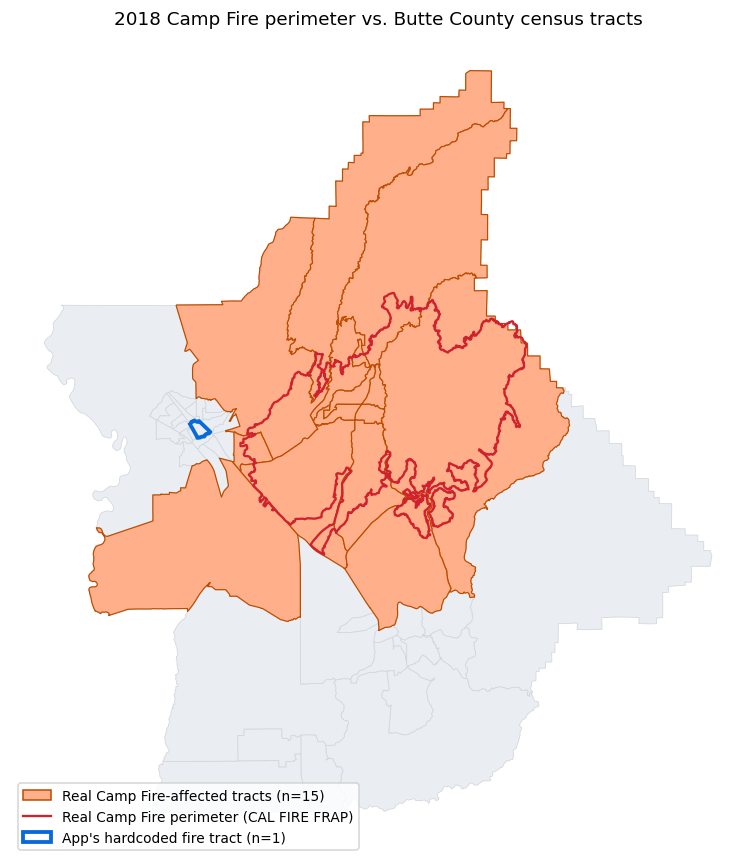

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
butte.plot(ax=ax, color="#eaeef2", edgecolor="#d0d7de", linewidth=0.5)
affected.plot(ax=ax, color="#ffb08a", edgecolor="#bc4c00", linewidth=0.8)
fire_proj.boundary.plot(ax=ax, color="#cf222e", linewidth=1.5)
hardcoded.plot(ax=ax, facecolor="none", edgecolor="#0969da", linewidth=2.5)
ax.set_title("2018 Camp Fire perimeter vs. Butte County census tracts", fontsize=12)
ax.set_axis_off()

legend_handles = [
    Patch(facecolor="#ffb08a", edgecolor="#bc4c00", label="Real Camp Fire-affected tracts (n=15)"),
    Line2D([0], [0], color="#cf222e", lw=1.5, label="Real Camp Fire perimeter (CAL FIRE FRAP)"),
    Patch(facecolor="none", edgecolor="#0969da", lw=2.5, label="App's hardcoded fire tract (n=1)"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig("../images/camp_fire_tract_map.png", dpi=130)
plt.show()


## 3. Does the vulnerability data support prioritizing this area?

Using the ACS data already committed to this repo, we compare the real
affected tracts against the rest of Butte County on the same three flags
the matching formula's `vFit` term uses.

**Important caveat:** this ACS data is a 2023 5-year estimate, not a 2018
snapshot -- Paradise's population and composition changed substantially
after the disaster (many residents never returned), so this isn't a
reconstruction of pre-fire conditions. It's a check on whether the same
geographic area still looks disproportionately vulnerable years later, read
alongside the independently sourced pre-fire demographic record cited in
Section 1 (about a quarter of Paradise's population was elderly, well above
county and state averages, even before the fire).


In [5]:
cols = ["Percent of Households with Elderly", "Percent of Population with Disability",
        "Percent of Households without Vehicle", "total_flags"]
unaffected = butte[~affected_mask]

comparison = pd.DataFrame({
    "Real affected tracts (n=15)": affected[cols].mean(),
    "Rest of Butte County (n=39)": unaffected[cols].mean(),
    "Butte County-wide (n=54)": butte[cols].mean(),
}).round(1)
comparison


,Real affected tracts (n=15),Rest of Butte County (n=39),Butte County-wide (n=54)
Percent of Households with Elderly,46.5,31.4,35.6
Percent of Population with Disability,17.2,16.9,17.0
Percent of Households without Vehicle,4.4,6.5,5.9
total_flags,0.9,0.7,0.8


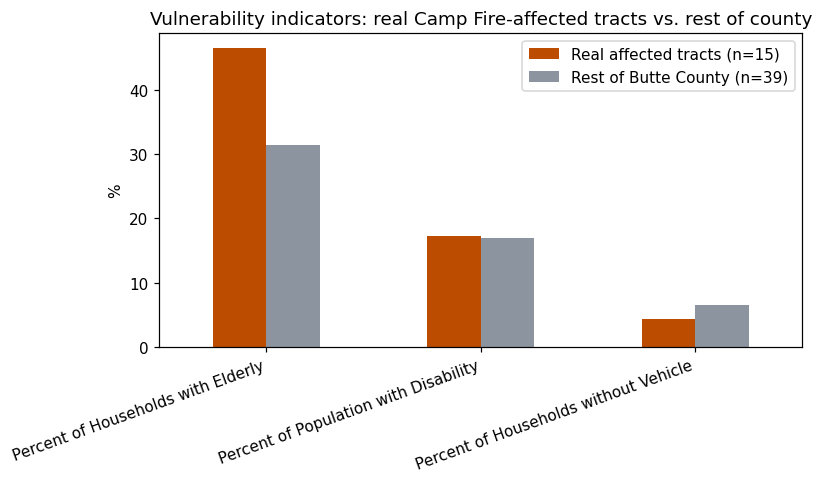

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_cols = ["Percent of Households with Elderly", "Percent of Population with Disability",
             "Percent of Households without Vehicle"]
comparison.loc[plot_cols, ["Real affected tracts (n=15)", "Rest of Butte County (n=39)"]].plot(
    kind="bar", ax=ax, color=["#bc4c00", "#8c959f"]
)
ax.set_ylabel("%")
ax.set_title("Vulnerability indicators: real Camp Fire-affected tracts vs. rest of county")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../images/camp_fire_vulnerability_comparison.png", dpi=120)
plt.show()


Reading it honestly, the signal is mixed, not uniformly confirming:

- **Elderly households: 46.5% vs. 31.4%** in the rest of the county -- a
  substantial gap, and consistent with the pre-fire record.
- **Disability: 17.2% vs. 16.9%** -- essentially flat, no real signal here.
- **No-vehicle households: 4.4% vs. 6.5%** -- actually *lower* in the
  affected tracts, the opposite of what a simple "vulnerable area" story
  would predict.
- **`total_flags` (the app's own composite): 0.93 vs. 0.72`** -- modestly
  higher, driven almost entirely by the elderly dimension.

So the elderly-vulnerability rationale holds up under real data, years
after the fire and using a data source the fire itself doesn't bias. The
disability and no-vehicle dimensions don't show the same pattern here --
worth knowing before treating `vFit`'s three flags as equally predictive of
real risk.


## 4. Takeaways

- **The safety-constraint concept is well-motivated and the implementation
  is broken.** A single hardcoded tract per county cannot represent a real
  fire perimeter -- the actual Camp Fire crossed 15 tracts in Butte County
  alone, and the app's one hardcoded "fire zone" tract wasn't even among
  them. This is direct, real-world evidence (not just a hypothetical) for
  why fire-zone data needs to come from a live perimeter feed rather than a
  constant in the source -- the same conclusion reached from a pure code
  audit, now backed by a real disaster.
- **A concrete, fixable bug**: the fire-warning banner's display text
  ("Census Tract 21") and the `FIRE_TRACTS` GEOID actually used for
  exclusion logic ("Census Tract 7") don't match. Worth a one-line fix
  independent of the larger live-feed work.
- **The vulnerability-weighting rationale is partially supported.** Elderly
  concentration lines up with both the real event and the documented cause
  of its death toll. Disability and vehicle-access don't show the same
  pattern in this specific event -- a reminder that `vFit`'s three flags
  aren't interchangeable evidence of risk, and any tuning of that formula
  should treat them separately rather than as one undifferentiated score.
- **No outcome metric is claimed here.** This notebook validates geospatial
  coverage and demographic rationale, not a counterfactual ("lives that
  would have been saved") -- that claim would require data this repo
  doesn't have and shouldn't pretend to.
